# Defining "Global Relationship" — Ground Truth for Step 1

Before fuzzy calibration, we need to define: **which families SHOULD be detected as having a global relationship?**

Problem: different families have very different MIC/dCor even at clean (no noise) conditions.
Some families (F19/F20 Spike, F25/F26 Multi-regime) have MIC < 0.85 even with zero noise.

This notebook:
1. Shows clean MIC/dCor for all 27 families
2. Visualizes the clean scatter plots for context
3. Defines ground truth labels for "has global relationship"
4. Determines what MIC/dCor thresholds best separate global vs non-global

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import warnings, os

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))
warnings.filterwarnings('ignore')

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')
OUT_DIR = Path('output/S3_polyfit')
OUT_DIR.mkdir(parents=True, exist_ok=True)

cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')
pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']

cases['snr_float'] = cases['snr'].apply(lambda x: float(x))
case_idx = pd.Series(np.arange(len(cases)), index=cases['case_id']).to_dict()

df = cases.merge(
    metrics[['case_id', 'MIC', 'MAS', 'distance_correlation',
             'pearson_r', 'spearman_rho']],
    on='case_id', how='inner')

ALL_FIDS = sorted(cases['family_id'].unique())
SHORT = {}
for fid in ALL_FIDS:
    row = cases[cases['family_id'] == fid].iloc[0]
    SHORT[fid] = str(row['family_name'])[:25]

print(f'Merged: {len(df):,} rows, {len(ALL_FIDS)} families')

Merged: 158,790 rows, 27 families


## 1. Clean Baseline — MIC & dCor at Zero Noise (SNR = ∞, strong variant)

Each family's "true" MIC and dCor with absolutely no noise, using the **strong** variant
(strongest feature expression). This gives the best-case detectability for each relationship type.

In [2]:
# Clean = SNR = inf (zero noise), strong variant (or 'none' for Null)
clean = df[np.isinf(df['snr_float']) &
           (df['variant_level'].isin(['strong', 'none']))]

clean_agg = clean.groupby('family_id').agg(
    name=('family_name', 'first'),
    variant=('variant_name', 'first'),
    mic=('MIC', 'mean'),
    mic_std=('MIC', 'std'),
    dcor=('distance_correlation', 'mean'),
    dcor_std=('distance_correlation', 'std'),
    pearson=('pearson_r', lambda x: x.abs().mean()),
    spearman=('spearman_rho', lambda x: x.abs().mean()),
    mas=('MAS', 'mean'),
    n=('case_id', 'count'),
).round(3)

print('══ Clean MIC & dCor (SNR = ∞, strong variant) ══')
print()
display(clean_agg[['name', 'variant', 'mic', 'mic_std', 'dcor', 'dcor_std', 'pearson', 'spearman', 'mas', 'n']])

══ Clean MIC & dCor (SNR = ∞, strong variant) ══



,name,variant,mic,mic_std,dcor,dcor_std,pearson,spearman,mas,n
family_id,,,,,,,,,,
F01,Linear positive,slope_3,1.000,0.000,1.000,0.000,1.000,1.000,0.000,10
F02,Linear negative,slope_3,1.000,0.000,1.000,0.000,1.000,1.000,0.000,10
F03,Power convex positive,p_4,1.000,0.000,0.917,0.005,0.868,1.000,0.000,10
F04,Power convex negative,p_4,1.000,0.000,0.916,0.007,0.866,1.000,0.000,10
F05,Power concave positive,p_0.15,1.000,0.000,0.970,0.003,0.920,1.000,0.000,10
F06,Power concave negative,p_0.15,1.000,0.000,0.970,0.002,0.922,1.000,0.000,10
F07,Saturation positive,k_15,1.000,0.000,0.686,0.016,0.593,1.000,0.001,10
F08,Saturation negative,k_15,1.000,0.000,0.684,0.012,0.582,1.000,0.000,10
F09,Log positive,a_50,1.000,0.000,0.964,0.002,0.919,1.000,0.000,10


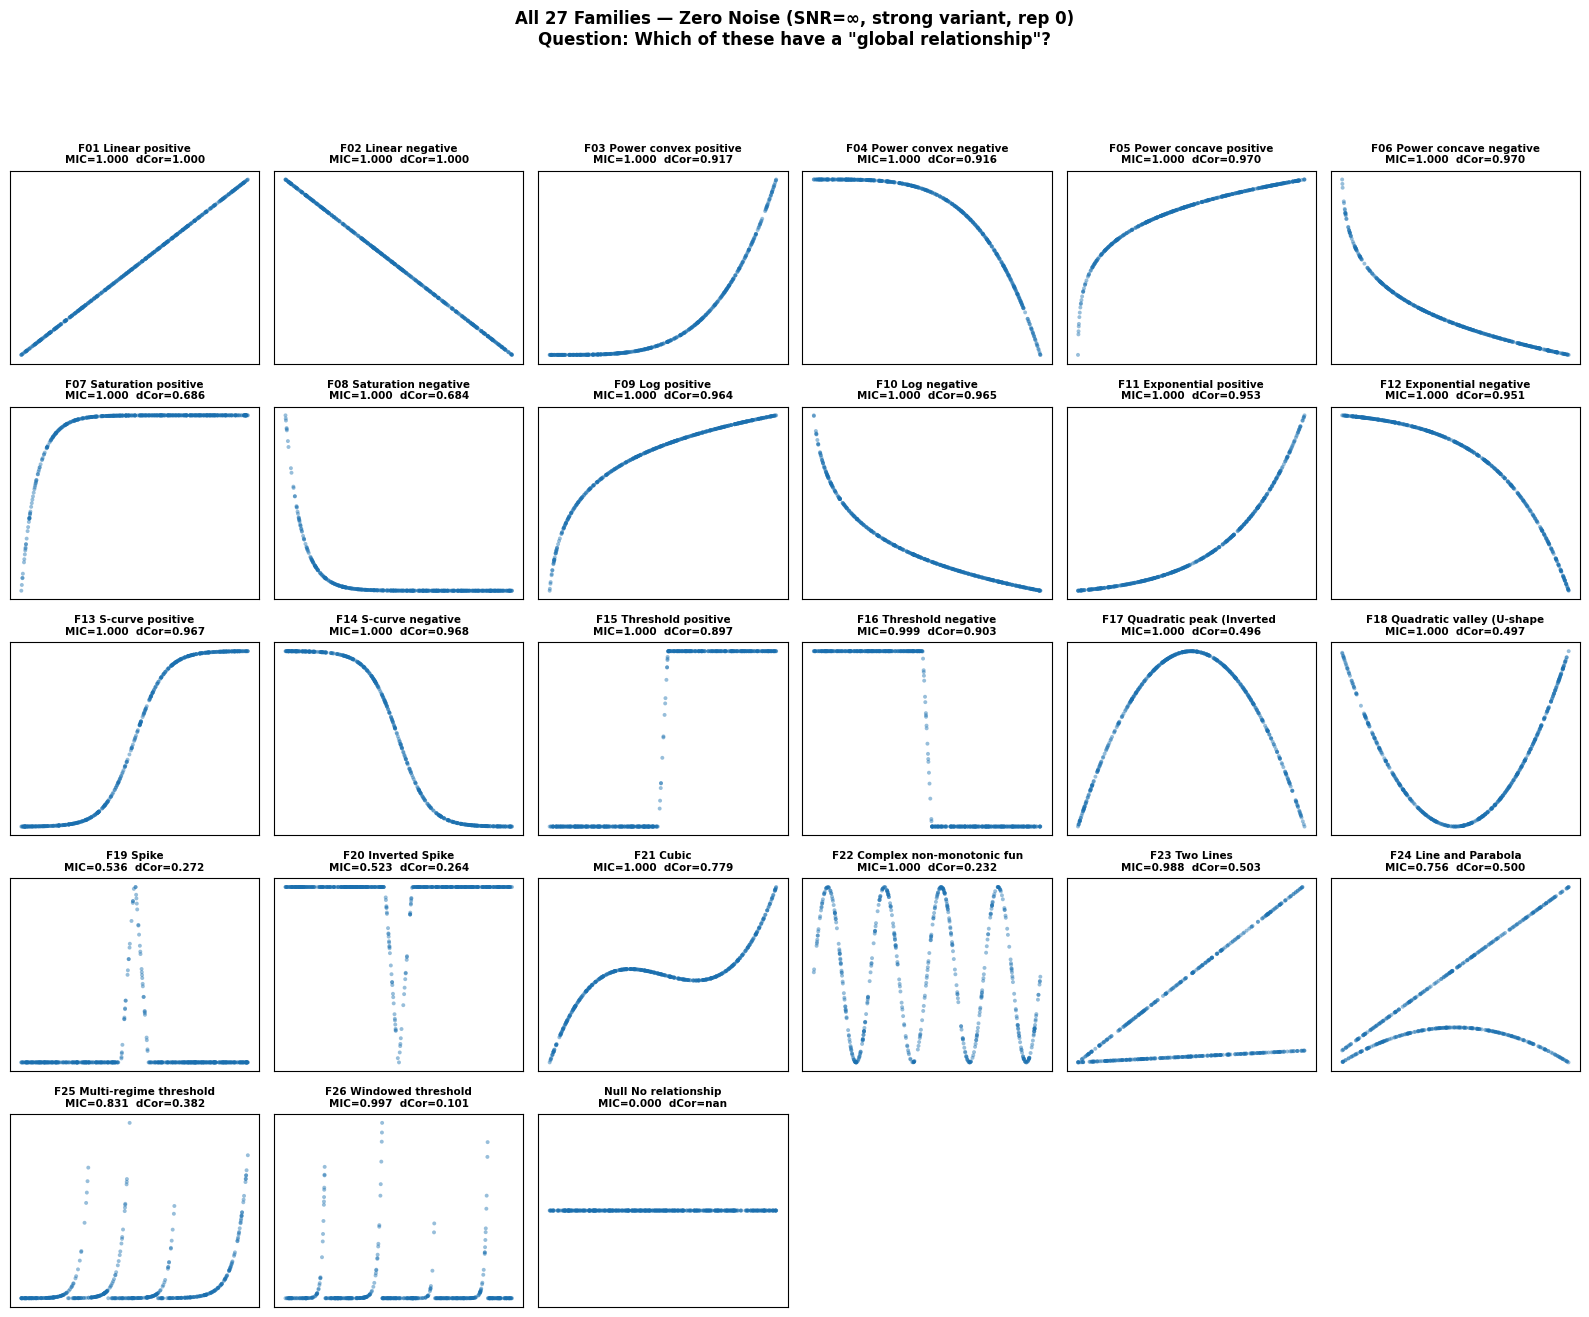

In [3]:
# Show clean scatter plots (SNR=inf, strong variant, rep 0) for all families
clean_cases = cases[
    np.isinf(cases['snr_float']) &
    (cases['variant_level'].isin(['strong', 'none'])) &
    (cases['replicate'] == 0)
]

fig, axes = plt.subplots(5, 6, figsize=(16, 13))
fig.suptitle('All 27 Families — Zero Noise (SNR=∞, strong variant, rep 0)\n'
             'Question: Which of these have a "global relationship"?',
             fontsize=12, fontweight='bold', y=1.01)

for ax, fid in zip(axes.flat, ALL_FIDS):
    match = clean_cases[clean_cases['family_id'] == fid]
    if len(match) > 0:
        cid = match.iloc[0]['case_id']
        idx = case_idx[cid]
        ax.scatter(x_all[idx], y_all[idx], s=8, alpha=0.45,
                   color='#1a6faf', edgecolors='none')

    mic_val = clean_agg.loc[fid, 'mic'] if fid in clean_agg.index else float('nan')
    dcor_val = clean_agg.loc[fid, 'dcor'] if fid in clean_agg.index else float('nan')
    ax.set_title(f'{fid} {SHORT[fid]}\nMIC={mic_val:.3f}  dCor={dcor_val:.3f}',
                 fontsize=7.5, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(ALL_FIDS):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUT_DIR / 'global_definition_clean_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. MIC vs dCor — Natural Clustering

Plot clean MIC vs dCor for all families. This reveals natural groupings:
- **Top-right**: strong global (high MIC + high dCor)
- **Top-left**: functional but non-monotonic (high MIC, low dCor)
- **Bottom**: weak or no global relationship
- Null family as the "no relationship" reference

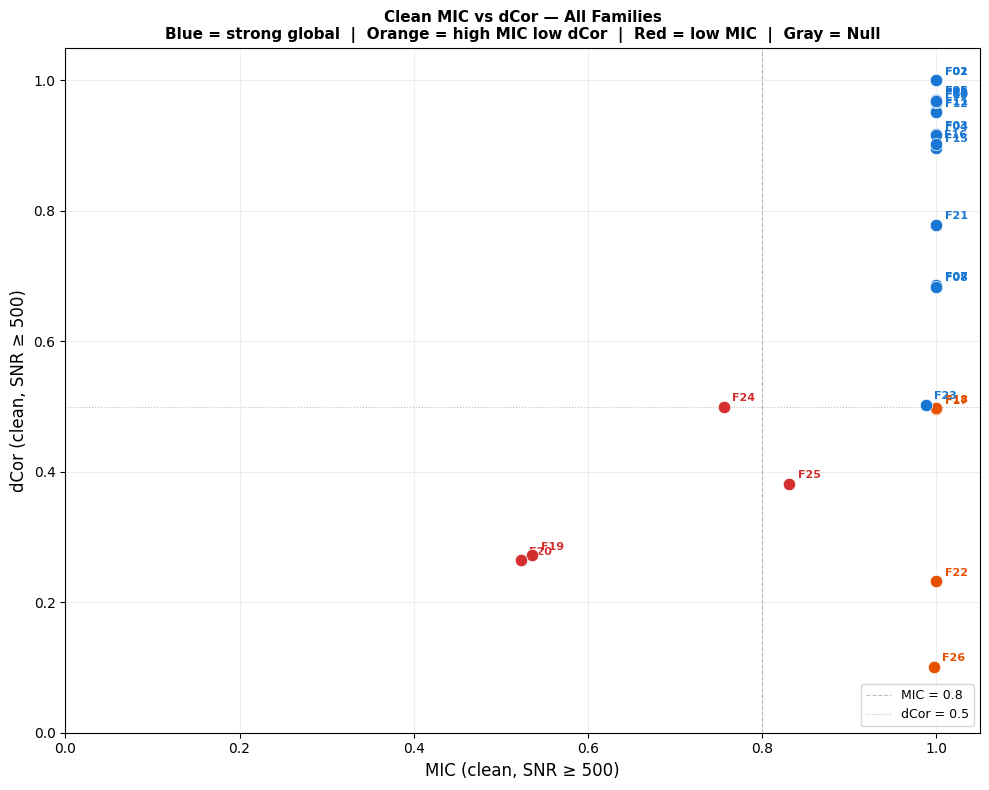

Observations:
  Blue (top-right): clear global relationship
  Orange (top-left): MIC detects pattern but dCor is low (non-monotonic)
  Red (low MIC): even MIC struggles to detect the pattern


In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

for fid in ALL_FIDS:
    if fid not in clean_agg.index:
        continue
    row = clean_agg.loc[fid]
    mic, dcor = row['mic'], row['dcor']

    color = '#1976D2'
    if fid == 'Null':
        color = '#888888'
    elif mic < 0.85:
        color = '#d32f2f'
    elif dcor < 0.5:
        color = '#E65100'

    ax.scatter(mic, dcor, s=80, color=color, zorder=5, edgecolors='white', linewidths=0.5)
    ax.annotate(f'{fid}', (mic, dcor),
                textcoords='offset points', xytext=(6, 4), fontsize=8,
                fontweight='bold', color=color)

# Reference lines
ax.axvline(0.8, color='gray', ls='--', lw=0.8, alpha=0.5, label='MIC = 0.8')
ax.axhline(0.5, color='gray', ls=':', lw=0.8, alpha=0.5, label='dCor = 0.5')

ax.set_xlabel('MIC (clean, SNR ≥ 500)', fontsize=12)
ax.set_ylabel('dCor (clean, SNR ≥ 500)', fontsize=12)
ax.set_title('Clean MIC vs dCor — All Families\n'
             'Blue = strong global  |  Orange = high MIC low dCor  |  '
             'Red = low MIC  |  Gray = Null',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0.0, 1.05)
ax.set_ylim(0.0, 1.05)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(OUT_DIR / 'global_definition_mic_vs_dcor.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observations:')
print('  Blue (top-right): clear global relationship')
print('  Orange (top-left): MIC detects pattern but dCor is low (non-monotonic)')
print('  Red (low MIC): even MIC struggles to detect the pattern')

## 3. Ground Truth Definition

Based on the clean scatter plots and indicator values, define which families
have a "global relationship" that Step 1 should detect.

**Key question**: "Global relationship" = there exists a consistent functional
pattern across the entire x range that a human can recognize.

Consider:
- F15/F16 (Threshold): sharp transition — IS there a global trend, or is it two flat regions?
- F17/F18 (U-shape): symmetric — MIC=1.0 but |r|≈0, dCor≈0.5
- F19/F20 (Spike): very localized — is this "global"?
- F22 (Complex non-monotonic): MIC=1.0 but dCor=0.43
- F23/F24 (Two Lines): piecewise — MIC=0.70–0.84
- F25/F26 (Multi-regime): MIC=0.77–0.78, dCor very low

In [5]:
# ════════════════════════════════════════════════════════
# EDIT THIS: Define which families have global relationship
# ════════════════════════════════════════════════════════
# 'yes'       = has global relationship (Step 1 should detect it)
# 'no'        = no global relationship (Step 1 should reject it)
# 'ambiguous' = borderline (discuss with supervisor)
#
# Values below are from SNR=∞, strong variant

HAS_GLOBAL = {
    # ── Clear global relationship ──
    'F01': 'yes',   # Linear positive        — MIC=1.000, dCor=1.000
    'F02': 'yes',   # Linear negative        — MIC=1.000, dCor=1.000
    'F03': 'yes',   # Power convex positive  — MIC=1.000, dCor=0.917
    'F04': 'yes',   # Power convex negative  — MIC=1.000, dCor=0.916
    'F05': 'yes',   # Power concave positive — MIC=1.000, dCor=0.970
    'F06': 'yes',   # Power concave negative — MIC=1.000, dCor=0.970
    'F07': 'yes',   # Saturation positive    — MIC=1.000, dCor=0.686
    'F08': 'yes',   # Saturation negative    — MIC=1.000, dCor=0.684
    'F09': 'yes',   # Log positive           — MIC=1.000, dCor=0.964
    'F10': 'yes',   # Log negative           — MIC=1.000, dCor=0.965
    'F11': 'yes',   # Exponential positive   — MIC=1.000, dCor=0.953
    'F12': 'yes',   # Exponential negative   — MIC=1.000, dCor=0.951
    'F13': 'yes',   # S-curve positive       — MIC=1.000, dCor=0.967
    'F14': 'yes',   # S-curve negative       — MIC=1.000, dCor=0.968

    # ── Questionable ──
    'F15': 'ambiguous',   # Threshold positive  — MIC=1.000, dCor=0.897
    'F16': 'ambiguous',   # Threshold negative  — MIC=0.999, dCor=0.903
    'F17': 'yes',         # Inverted-U          — MIC=1.000, dCor=0.496
    'F18': 'yes',         # U-shape             — MIC=1.000, dCor=0.497
    'F19': 'ambiguous',   # Spike               — MIC=0.536, dCor=0.272
    'F20': 'ambiguous',   # Inverted Spike      — MIC=0.523, dCor=0.264
    'F21': 'yes',         # Cubic               — MIC=1.000, dCor=0.779
    'F22': 'ambiguous',   # Complex non-mono    — MIC=1.000, dCor=0.232

    # ── Likely no single global relationship ──
    'F23': 'ambiguous',   # Two Lines           — MIC=0.988, dCor=0.503
    'F24': 'ambiguous',   # Line and Parabola   — MIC=0.756, dCor=0.500
    'F25': 'ambiguous',   # Multi-regime thresh — MIC=0.831, dCor=0.382
    'F26': 'ambiguous',   # Windowed threshold  — MIC=0.997, dCor=0.101

    # ── No relationship ──
    'Null': 'no',
}

# Show the definition
gt_df = pd.DataFrame([
    {'family_id': fid, 'name': SHORT[fid],
     'has_global': HAS_GLOBAL[fid],
     'clean_mic': clean_agg.loc[fid, 'mic'] if fid in clean_agg.index else np.nan,
     'clean_dcor': clean_agg.loc[fid, 'dcor'] if fid in clean_agg.index else np.nan}
    for fid in ALL_FIDS
])

print('══ Ground Truth: Global Relationship Definition ══')
print()
for label, desc in [('yes', 'HAS global'), ('ambiguous', 'AMBIGUOUS (needs decision)'), ('no', 'NO global')]:
    sub = gt_df[gt_df['has_global'] == label]
    print(f'\n── {desc} ({len(sub)} families) ──')
    for _, r in sub.iterrows():
        mic = f'{r["clean_mic"]:.3f}' if pd.notna(r['clean_mic']) else '?'
        dcor = f'{r["clean_dcor"]:.3f}' if pd.notna(r['clean_dcor']) else '?'
        print(f'  {r["family_id"]}  {r["name"]:<28s} MIC={mic}  dCor={dcor}')

══ Ground Truth: Global Relationship Definition ══


── HAS global (17 families) ──
  F01  Linear positive              MIC=1.000  dCor=1.000
  F02  Linear negative              MIC=1.000  dCor=1.000
  F03  Power convex positive        MIC=1.000  dCor=0.917
  F04  Power convex negative        MIC=1.000  dCor=0.916
  F05  Power concave positive       MIC=1.000  dCor=0.970
  F06  Power concave negative       MIC=1.000  dCor=0.970
  F07  Saturation positive          MIC=1.000  dCor=0.686
  F08  Saturation negative          MIC=1.000  dCor=0.684
  F09  Log positive                 MIC=1.000  dCor=0.964
  F10  Log negative                 MIC=1.000  dCor=0.965
  F11  Exponential positive         MIC=1.000  dCor=0.953
  F12  Exponential negative         MIC=1.000  dCor=0.951
  F13  S-curve positive             MIC=1.000  dCor=0.967
  F14  S-curve negative             MIC=1.000  dCor=0.968
  F17  Quadratic peak (Inverted     MIC=1.000  dCor=0.496
  F18  Quadratic valley (U-shape    MIC=1.000 

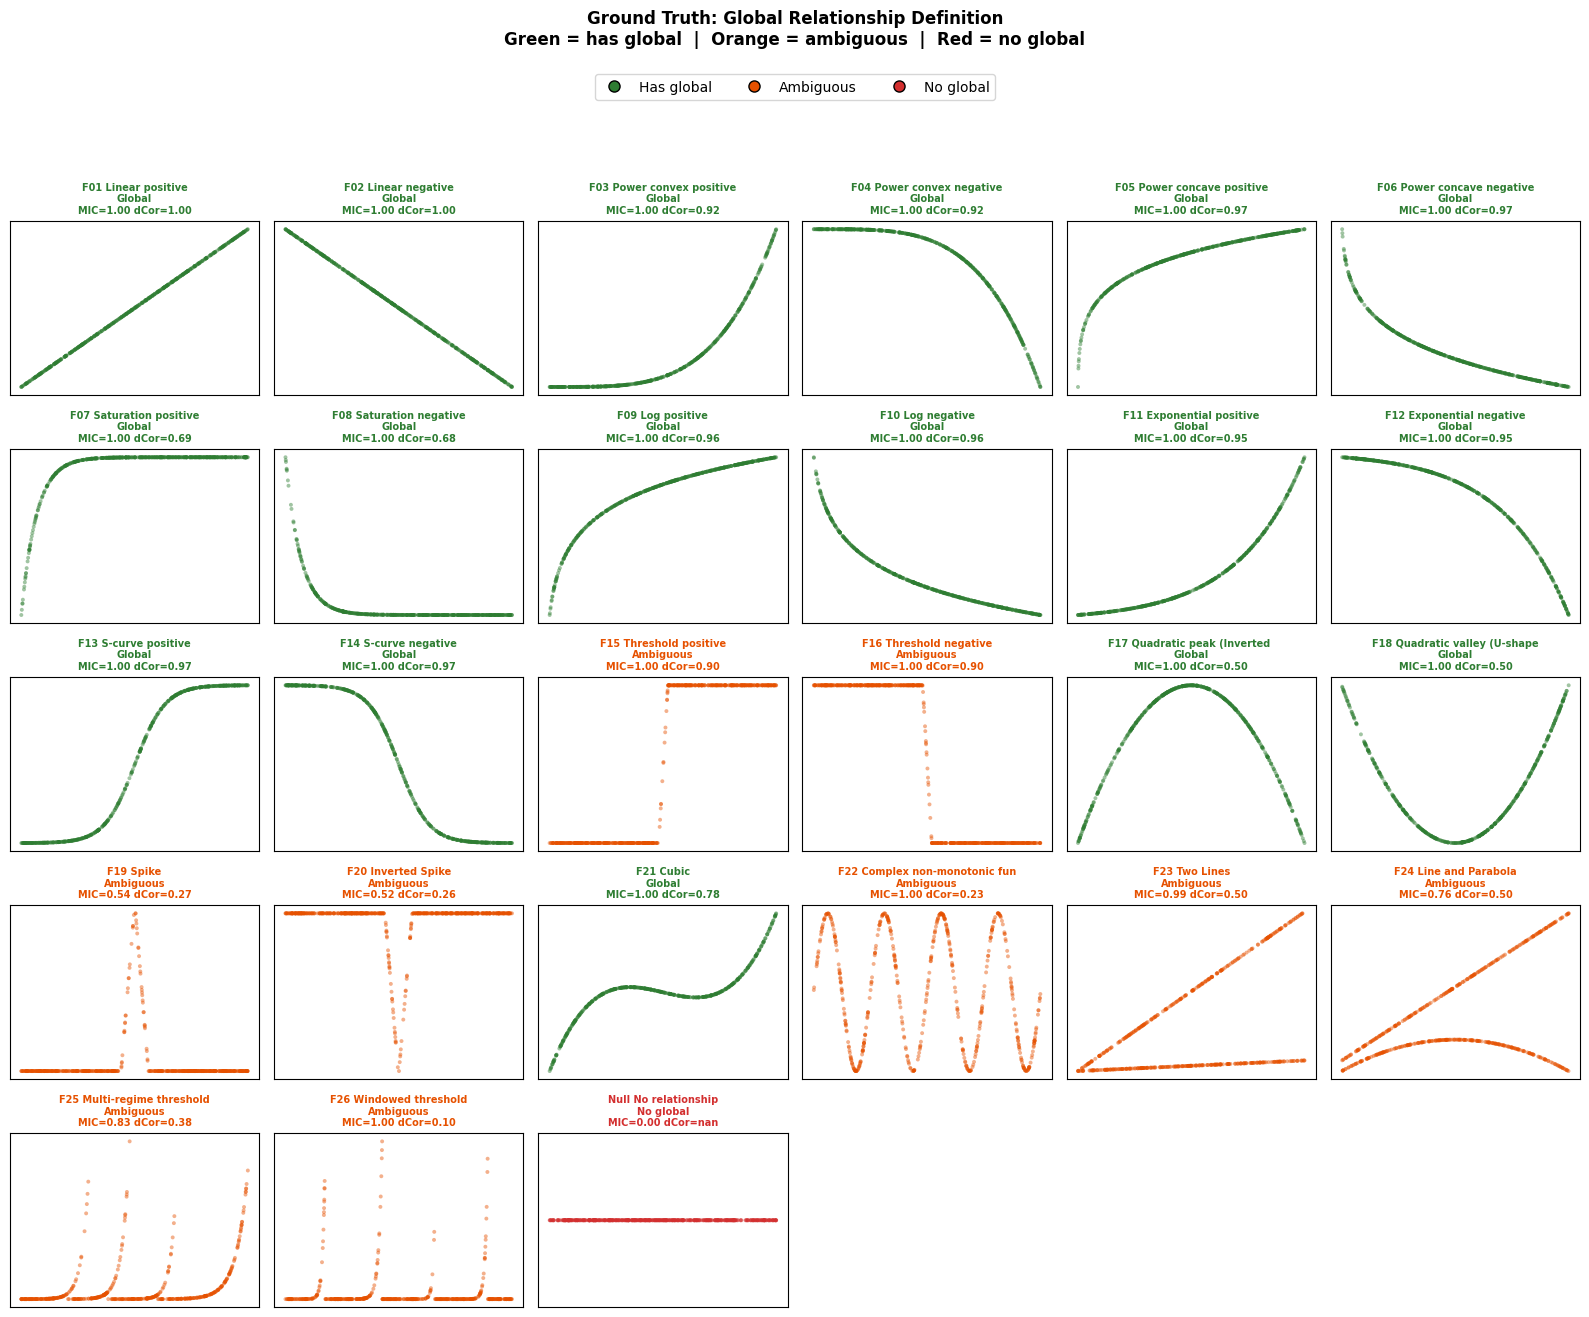

In [6]:
# ── Scatter plots colored by ground truth ──
C_GLOBAL = '#2e7d32'
C_NO_GLOBAL = '#d32f2f'
C_AMBIGUOUS = '#E65100'

fig, axes = plt.subplots(5, 6, figsize=(16, 13))
fig.suptitle('Ground Truth: Global Relationship Definition\n'
             'Green = has global  |  Orange = ambiguous  |  Red = no global',
             fontsize=12, fontweight='bold', y=1.01)

for ax, fid in zip(axes.flat, ALL_FIDS):
    gt = HAS_GLOBAL.get(fid, 'ambiguous')
    if gt == 'yes':
        color, label = C_GLOBAL, 'Global'
    elif gt == 'no':
        color, label = C_NO_GLOBAL, 'No global'
    else:
        color, label = C_AMBIGUOUS, 'Ambiguous'

    match = clean_cases[clean_cases['family_id'] == fid]
    if len(match) > 0:
        cid = match.iloc[0]['case_id']
        idx = case_idx[cid]
        ax.scatter(x_all[idx], y_all[idx], s=8, alpha=0.45,
                   color=color, edgecolors='none')

    mic_val = clean_agg.loc[fid, 'mic'] if fid in clean_agg.index else float('nan')
    dcor_val = clean_agg.loc[fid, 'dcor'] if fid in clean_agg.index else float('nan')
    ax.set_title(f'{fid} {SHORT[fid]}\n{label}\nMIC={mic_val:.2f} dCor={dcor_val:.2f}',
                 fontsize=7, fontweight='bold', color=color)
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes.flat[len(ALL_FIDS):]:
    ax.set_visible(False)

handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=c, markersize=8, label=l)
           for l, c in [('Has global', C_GLOBAL), ('Ambiguous', C_AMBIGUOUS), ('No global', C_NO_GLOBAL)]]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=10,
           frameon=True, bbox_to_anchor=(0.5, 0.965))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / 'global_definition_ground_truth.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. What MIC / dCor Threshold Best Separates Global vs Non-global?

Given the ground truth labels above, find the threshold that maximizes
separation between "has global" and "no global / ambiguous" families.

This replaces the arbitrary MIC ≥ 0.8 with an empirically justified cutoff.

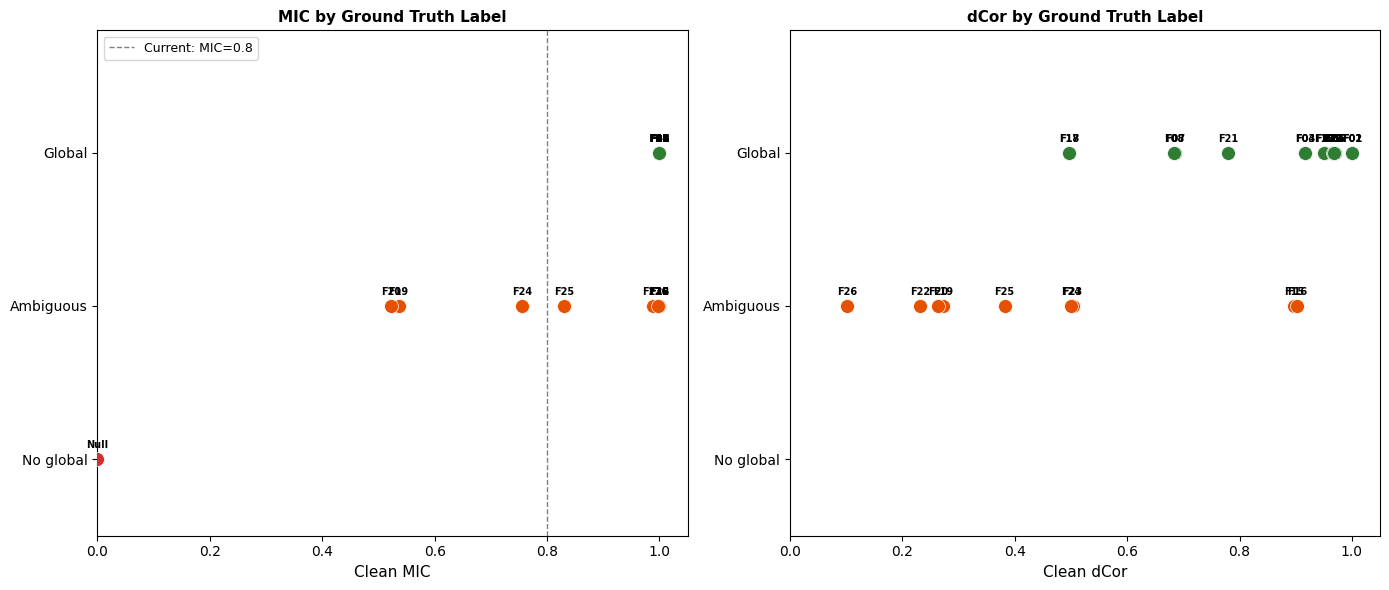

── MIC Analysis ──
Global families (yes):      MIC = [1.000, 1.000], min=1.000
No-global families (no):    MIC = [0.000, 0.000]
Ambiguous families:         MIC = [0.523, 1.000]

── dCor Analysis ──
Global families (yes):      dCor = [0.496, 1.000], min=0.496
Ambiguous families:         dCor = [0.101, 0.903]

NOTE: The ambiguous families need a decision before finalizing.
Once decided, update HAS_GLOBAL above and re-run.


In [7]:
# Only use families with definitive labels (yes/no)
# Ambiguous shown separately
definite = gt_df[gt_df['has_global'].isin(['yes', 'no'])].copy()
definite['is_global'] = definite['has_global'] == 'yes'
ambiguous = gt_df[gt_df['has_global'] == 'ambiguous'].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: MIC by label
y_map = {'yes': 2, 'ambiguous': 1, 'no': 0}
y_labels = ['No global', 'Ambiguous', 'Global']

for label, color, y_pos in [('yes', C_GLOBAL, 2), ('no', C_NO_GLOBAL, 0)]:
    sub = gt_df[gt_df['has_global'] == label]
    ax1.scatter(sub['clean_mic'], [y_pos] * len(sub), s=100, color=color,
                zorder=5, edgecolors='white', linewidths=0.5)
    for _, r in sub.iterrows():
        ax1.annotate(r['family_id'], (r['clean_mic'], y_pos),
                     textcoords='offset points', xytext=(0, 8), fontsize=7,
                     ha='center', fontweight='bold')

if len(ambiguous) > 0:
    ax1.scatter(ambiguous['clean_mic'], [1] * len(ambiguous), s=100,
                color=C_AMBIGUOUS, zorder=5, edgecolors='white', linewidths=0.5)
    for _, r in ambiguous.iterrows():
        ax1.annotate(r['family_id'], (r['clean_mic'], 1),
                     textcoords='offset points', xytext=(0, 8), fontsize=7,
                     ha='center', fontweight='bold')

ax1.axvline(0.8, color='gray', ls='--', lw=1, label='Current: MIC=0.8')
ax1.set_xlabel('Clean MIC', fontsize=11)
ax1.set_title('MIC by Ground Truth Label', fontsize=11, fontweight='bold')
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(y_labels)
ax1.legend(fontsize=9)
ax1.set_xlim(0, 1.05)
ax1.set_ylim(-0.5, 2.8)

# Right: dCor by label
for label, color, y_pos in [('yes', C_GLOBAL, 2), ('no', C_NO_GLOBAL, 0)]:
    sub = gt_df[gt_df['has_global'] == label]
    ax2.scatter(sub['clean_dcor'], [y_pos] * len(sub), s=100, color=color,
                zorder=5, edgecolors='white', linewidths=0.5)
    for _, r in sub.iterrows():
        ax2.annotate(r['family_id'], (r['clean_dcor'], y_pos),
                     textcoords='offset points', xytext=(0, 8), fontsize=7,
                     ha='center', fontweight='bold')

if len(ambiguous) > 0:
    ax2.scatter(ambiguous['clean_dcor'], [1] * len(ambiguous), s=100,
                color=C_AMBIGUOUS, zorder=5, edgecolors='white', linewidths=0.5)
    for _, r in ambiguous.iterrows():
        ax2.annotate(r['family_id'], (r['clean_dcor'], 1),
                     textcoords='offset points', xytext=(0, 8), fontsize=7,
                     ha='center', fontweight='bold')

ax2.set_xlabel('Clean dCor', fontsize=11)
ax2.set_title('dCor by Ground Truth Label', fontsize=11, fontweight='bold')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(y_labels)
ax2.set_xlim(0, 1.05)
ax2.set_ylim(-0.5, 2.8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'global_definition_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

# Print analysis
global_mics = definite[definite['is_global']]['clean_mic'].dropna()
no_global_mics = definite[~definite['is_global']]['clean_mic'].dropna()
ambig_mics = ambiguous['clean_mic'].dropna()

print('── MIC Analysis ──')
print(f'Global families (yes):      MIC = [{global_mics.min():.3f}, {global_mics.max():.3f}], min={global_mics.min():.3f}')
if len(no_global_mics) > 0:
    print(f'No-global families (no):    MIC = [{no_global_mics.min():.3f}, {no_global_mics.max():.3f}]')
if len(ambig_mics) > 0:
    print(f'Ambiguous families:         MIC = [{ambig_mics.min():.3f}, {ambig_mics.max():.3f}]')
print()

global_dcors = definite[definite['is_global']]['clean_dcor'].dropna()
no_global_dcors = definite[~definite['is_global']]['clean_dcor'].dropna()
ambig_dcors = ambiguous['clean_dcor'].dropna()

print('── dCor Analysis ──')
print(f'Global families (yes):      dCor = [{global_dcors.min():.3f}, {global_dcors.max():.3f}], min={global_dcors.min():.3f}')
if len(no_global_dcors) > 0:
    print(f'No-global families (no):    dCor = [{no_global_dcors.min():.3f}, {no_global_dcors.max():.3f}]')
if len(ambig_dcors) > 0:
    print(f'Ambiguous families:         dCor = [{ambig_dcors.min():.3f}, {ambig_dcors.max():.3f}]')

print()
print('NOTE: The ambiguous families need a decision before finalizing.')
print('Once decided, update HAS_GLOBAL above and re-run.')

## Summary & Next Steps

1. **Define ground truth** (edit `HAS_GLOBAL` dict above) — decide the ambiguous cases
2. **Clean MIC/dCor** shows inherent detectability per family
3. **Threshold** should separate global vs non-global at clean conditions
4. **Fuzzy calibration** (next notebook) uses these labels + noise degradation

Key insight: the MIC ≥ 0.8 threshold may need to change depending on
which families you define as having a global relationship.